<a href="https://colab.research.google.com/github/joaonetto/projetoAplicado-IV/blob/main/notebook/project-UserBehaviourAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://raw.githubusercontent.com/joaonetto/projetoAplicado-IV/refs/heads/main/Images/Mackenzie.png" width="25%" align="left"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2026/01**

---

# **Titulo do Projeto**:

### ***ChronoSec***: Detecção Comportamental e Séries Temporais para Segurança de Login (UEBA) em Eventos Google
---

**Projeto**: *User Behaviour Analysis*

---

In [1]:
#@title **Identificação do Grupo e Opção do Projeto**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: \<nome\>, \<matrícula\>*)
Aluno1 = 'João Silveira Campos Netto, 10441670' #@param {type:"string"}
Aluno2 = 'Alex Luiz Rabelo, 10442968' #@param {type:"string"}
Aluno3 = 'Antônio Henrique Caldas Mello, 10433799' #@param {type:"string"}

# Introdução

Este projeto investiga a detecção de anomalias em processos de autenticação a partir de logs de *login*, com ênfase na construção de perfis temporais de usuários fundamentados no conceito de **User Behaviour Analysis** (**UBA**). O principal motivador reside na necessidade de aprimorar a capacidade de detecção e resposta a possíveis comprometimentos de credenciais e abusos de acesso em ambientes corporativos, reduzindo limitações de abordagens baseadas em regras fixas, as quais tendem a produzir elevada taxa de falsos positivos diante da heterogeneidade de hábitos individuais. Assim, o objetivo geral consiste em aprender, de forma adaptativa, padrões comportamentais por usuário e derivar um *score* de risco interpretável para cada evento de autenticação, com vistas a subsidiar a priorização de casos potencialmente críticos.

A proposta adota uma perspectiva de **séries temporais orientada a eventos**, na qual cada ocorrência de *login* é tratada como uma observação inserida em ciclos recorrentes de atividade, como hora do dia e dia da semana. No âmbito de **UBA**, tais regularidades constituem evidências do comportamento típico de cada identidade, permitindo a formulação de um baseline individualizado. Desse modo, o projeto busca representar a normalidade de forma específica por usuário, de modo a acomodar variações legítimas de rotina sem comprometer a sensibilidade à identificação de desvios relevantes do ponto de vista de segurança.

Para viabilizar a construção desses perfis, o núcleo metodológico emprega **redes neurais recorrentes** do tipo **Long Short-Term Memory** (**LSTM**) em configuração de *autoencoder*, treinadas para reconstruir características temporais representadas de forma cíclica (por exemplo, componentes seno e cosseno associados aos ciclos diários e semanais). Nesse contexto, a etapa de *encoding* desempenha papel central: o encoder **LSTM** atua como um mecanismo de compressão e abstração do comportamento temporal, transformando as observações em uma representação latente que concentra as regularidades do usuário e atenua variações não sistemáticas (**ruído**). Em termos práticos, essa representação latente funciona como uma **“assinatura”** do perfil, na qual o modelo codifica relações implícitas entre os ciclos (por exemplo, preferência por janelas específicas de horário em determinados dias), bem como a consistência com que tais padrões se repetem no histórico.

A importância do encoder **LSTM** para **UBA** decorre, adicionalmente, de sua capacidade de capturar dependências temporais e preservar contexto por meio de seus mecanismos de memória (portas de entrada, esquecimento e saída). Mesmo quando o problema é tratado como uma sequência curta (ou evento pontual inserido em um fluxo), o encoder contribui para mapear a observação em um espaço onde **“proximidade”** representa semelhança comportamental: eventos compatíveis com o hábito do usuário tendem a ocupar regiões latentes próximas às rotinas aprendidas, enquanto eventos atípicos tendem a ser codificados como padrões menos consistentes com o **manifold** (uma variedade é um espaço topológico que se parece localmente com um espaço euclidiano nas vizinhanças de cada ponto) do comportamento normal. Assim, o *encoder* não apenas reduz dimensionalidade, mas também organiza o espaço de comportamento, permitindo que o *decoder* reconstrua com alta fidelidade aquilo que é recorrente e falhe (com erro mensurável) diante do incomum.

A hipótese central é que, ao aprender essa assinatura temporal, eventos compatíveis com o perfil são reconstruídos com baixo erro, ao passo que acessos fora do padrão produzem maior erro de reconstrução. Dessa forma, o erro de reconstrução é utilizado como proxy quantitativo de desvio comportamental em um cenário predominantemente não supervisionado. A partir dessa medida de desvio, o projeto estabelece um mecanismo de pontuação contínua para apoiar a interpretação e a tomada de decisão. O *score* gerado possibilita definir limiares de interesse e organizar a triagem de eventos, além de permitir a agregação por usuário para identificação de identidades com maior recorrência ou intensidade de ocorrências atípicas. Essa estrutura contribui para a sistematização da análise e para a redução do esforço manual, ao transformar registros de autenticação em indicadores comparáveis e operacionalmente acionáveis.

# Referencial Teórico



O presente projeto tem como propósito modelar o comportamento habitual de autenticação de usuários a partir da perspectiva de **User Behaviour Analysis (UBA)**, considerando os _logs_ de _login_ como uma série temporal orientada a eventos. Sua motivação central decorre da necessidade de aprimorar a capacidade de detecção e priorização de comportamentos atípicos, potencialmente associados ao comprometimento de credenciais, ao uso indevido de contas ou a processos automatizados de abuso. Em ambientes corporativos heterogêneos, nos quais diferentes usuários apresentam rotinas, horários e padrões de acesso distintos, abordagens baseadas exclusivamente em regras fixas tendem a produzir elevada taxa de falsos positivos. Nesse contexto, torna-se necessário desenvolver mecanismos analíticos mais adaptativos, capazes de aprender regularidades individuais e, a partir delas, identificar desvios com maior precisão e coerência operacional.

O objetivo geral da proposta consiste em construir perfis temporais individualizados com base no histórico de acessos de cada usuário e, a partir desses perfis, gerar um _score_ de risco interpretável para cada evento de autenticação. Em termos práticos, tal pontuação busca apoiar processos de triagem, priorização e escalonamento de alertas, permitindo classificar eventos em diferentes níveis de criticidade, como normal, suspeito ou crítico. Essa abordagem contribui para tornar a análise mais reprodutível, menos dependente de julgamento exclusivamente manual e mais aderente às necessidades de monitoramento contínuo em operações de segurança.

Do ponto de vista metodológico, o núcleo da solução fundamenta-se na utilização de um _autoencoder_ baseado em redes neurais do tipo **LSTM**, treinado para reconstruir representações temporais codificadas ciclicamente, como hora do dia e dia da semana. A hipótese subjacente é que eventos compatíveis com o padrão histórico aprendido apresentem baixo erro de reconstrução, enquanto acessos que se distanciam do comportamento usual resultem em erros mais elevados. Dessa forma, o erro de reconstrução passa a ser interpretado como uma evidência quantitativa de desvio, permitindo converter a diferença entre o comportamento esperado e o observado em uma medida objetiva de risco. Essa estratégia é particularmente relevante em cenários nos quais o comportamento legítimo não é estático, mas sim dependente de ciclos temporais e hábitos específicos de cada usuário.

Os resultados do projeto são organizados em dois níveis analíticos complementares. No nível do evento, cada tentativa de autenticação recebe uma pontuação individual, permitindo a avaliação pontual do risco associado a um _login_ específico. No nível agregado, são produzidos indicadores por usuário, como valores máximos de desvio e frequências de ocorrências anômalas ao longo do tempo. Essa dupla perspectiva fortalece tanto o monitoramento contínuo quanto a rastreabilidade das evidências utilizadas em processos de investigação, favorecendo uma análise mais consistente da recorrência, intensidade e contexto dos desvios comportamentais observados.

No que se refere aos trabalhos relacionados, a literatura e o mercado apresentam iniciativas relevantes que dialogam com a proposta desenvolvida. Estudos como o trabalho da Okta ([Anomaly Detection in OKTA Logs using AutoEncoders](https://arxiv.org/html/2411.07314v1)) sobre detecção de anomalias em _logs_ por meio de _autoencoders_ evidenciam a aplicabilidade de métodos não supervisionados para identificação de padrões atípicos em eventos de autenticação. De forma complementar, soluções corporativas como o IBM ([Analytics de comportamento do usuário com o IBM QRadar SIEM](https://www.ibm.com/br-pt/products/qradar-siem/user-entity-behavior-analytics)) demonstram a consolidação do uso de _analytics_ comportamental em contextos de segurança, enquanto abordagens amplas de análise comportamental, como as promovidas pelo Google ([People Analytics](https://rework.withgoogle.com/intl/en/subjects/people-analytics)), reforçam a importância de extrair conhecimento a partir de padrões recorrentes de atividade humana. Embora cada uma dessas iniciativas possua escopo e objetivos específicos, todas contribuem para sustentar a relevância de abordagens baseadas em perfis dinâmicos e análise de desvios em contextos complexos.

Além da abordagem adotada neste projeto, existem alternativas metodológicas para tratar o mesmo problema, cada qual com vantagens e limitações. Estratégias baseadas em regras ou heurísticas, como a definição de um _baseline_ fixo para identificar _logins_ fora do horário comercial, apresentam simplicidade, baixo custo e elevada explicabilidade, sendo úteis como camada inicial de defesa. Contudo, sua baixa adaptabilidade e a necessidade de manutenção constante reduzem sua efetividade em ambientes diversos, além de torná-las suscetíveis a evasão por agentes maliciosos que imitam padrões básicos. Métodos estatísticos por usuário, fundamentados em características individuais e densidades de comportamento, oferecem melhor custo-benefício e maior interpretabilidade, sobretudo por estabelecerem baselines personalizados. Ainda assim, tendem a capturar com menor eficácia padrões complexos ou multimodais e podem sofrer com mudanças de rotina, especialmente na presença de _concept drift_ e amostras reduzidas.

Outra alternativa reside nos modelos clássicos de detecção de anomalias, os quais funcionam como ferramentas generalistas e podem ser úteis na aprendizagem de padrões estruturados em _logs_. Embora sejam uma referência consolidada, sua explicabilidade costuma ser limitada e sua performance depende fortemente da qualidade da engenharia de atributos. Além disso, quando as dependências temporais não são representadas adequadamente, tais modelos podem falhar em capturar nuances relevantes do comportamento. Também se destacam os modelos sequenciais por previsão, como o **DeepLog**, que se mostram eficazes na aprendizagem de sequências e da ordem dos eventos em _logs_ estruturados. Apesar disso, esses métodos exigem definição prévia de eventos ou _templates_, dependem de janelas e de ordenação adequadas e nem sempre são os mais apropriados quando o principal sinal de interesse está associado ao caráter cíclico do tempo, como horários de acesso e recorrência semanal.

Nesse panorama, a reconstrução com _autoencoders_ se mostra particularmente promissora para cenários não supervisionados e marcados por incerteza, como aqueles relacionados ao comportamento de autenticação. Suas principais vantagens residem na robustez para aprender assinaturas complexas do comportamento, na geração natural de um _score_ a partir do erro de reconstrução e na capacidade de adaptação a padrões não triviais. No contexto de **UBA**, essa característica é especialmente valiosa, pois permite modelar o comportamento habitual sem depender de rótulos prévios extensivos. Ainda assim, essa abordagem também apresenta limitações importantes, como a sensibilidade à definição de _thresholds_, o risco de absorver ruído quando os dados não são adequadamente filtrados e a necessidade de re-treinamento periódico para lidar com mudanças comportamentais ao longo do tempo. Ademais, sua explicabilidade não é inerente ao modelo, dependendo de estratégias adicionais de engenharia e interpretação.

Em síntese, a proposta deste projeto se insere em um campo analítico relevante para a segurança da informação, ao combinar modelagem temporal individualizada, aprendizado não supervisionado e produção de evidências quantitativas para apoiar a tomada de decisão. Ao privilegiar a construção de perfis adaptativos por usuário e a mensuração objetiva de desvios, o trabalho busca superar limitações de abordagens rígidas e contribuir para processos de monitoramento, triagem e investigação mais precisos, reprodutíveis e aderentes à complexidade dos ambientes digitais contemporâneos.

### Referências

SHARMA, Balaram; POKHAREL, Prabhat; JOSHI, Basanta. User behavior analytics for anomaly detection using LSTM autoencoder: insider threat detection. In: INTERNATIONAL CONFERENCE ON ADVANCES IN INFORMATION TECHNOLOGY, 11., 2020, Bangkok, Thailand. Proceedings […] New York, NY: ACM, 2020. p. 1-9. DOI: 10.1145/3406601.3406610. Disponível em: https://dl.acm.org/doi/epdf/10.1145/3406601.3406610. Acesso em: 25 fev. 2026.

DU, Min; LI, Feifei; ZHENG, Guineng; SRIKUMAR, Vivek. DeepLog: anomaly detection and diagnosis from system logs through deep learning. In: ACM SIGSAC CONFERENCE ON COMPUTER AND COMMUNICATIONS SECURITY, 24., 2017. Proceedings […] New York, NY: ACM, 2017. DOI: 10.1145/3133956.3134015. Disponível em: https://users.cs.utah.edu/~lifeifei/papers/deeplog.pdf. Acesso em: 26 fev. 2026.

GUO, Haixuan; YUAN, Shuhan; WU, Xintao. LogBERT: log anomaly detection via BERT. arXiv, 2021. DOI: 10.48550/arXiv.2103.04475. Disponível em: https://arxiv.org/pdf/2103.04475. Acesso em: 25 fev. 2026.

LANDAUER, Max; ONDER, Sebastian; SKOPIK, Florian; WURZENBERGER, Markus. Deep learning for anomaly detection in log data: a survey. arXiv, 2022. DOI: 10.48550/arXiv.2207.03820. Disponível em: https://arxiv.org/pdf/2207.03820. Acesso em: 27 fev. 2026.

KIM, Seo-Yi; LEE, Il-Gu. LSTM autoencoder-based insider abnormal behavior detection using de-identified data. In: INTERNATIONAL CONFERENCE ON INFORMATION SYSTEMS SECURITY AND PRIVACY, 10., 2024. Proceedings […] [S. l.]: SCITEPRESS, 2024. p. 609-620. DOI: 10.5220/0012458000003648. Disponível em: https://www.scitepress.org/Papers/2024/124580/124580.pdf. Acesso em: 23 fev. 2026.

CAIN, Jericho E.; BEADLES, Hayden; VENKATESAN, Karthik. Anomaly detection in OKTA logs using autoencoders. arXiv preprint, 2024. Disponível em: https://arxiv.org/html/2411.07314v1. Acesso em: 2 mar. 2026.

## Diagrama da Solução

<img src="https://github.com/joaonetto/projetoAplicado-IV/blob/main/Images/UserBehaviourAnalysis.jpg?raw=true" width="100%"/>

A figura apresentada descreve um cenário em que *logs* de autenticação, gerados como eventos em *streaming*, são ingeridos e encaminhados para um processo de **análise comportamental**. Nesta etapa, considera-se, como ponto de partida, a seleção de eventos do tipo ***login_success***, uma vez que o objetivo central deste componente do projeto é compreender padrões legítimos de uso a partir de acessos bem-sucedidos e, a partir disso, estimar o grau de aderência (ou desvio) desses acessos em relação ao comportamento **histórico** do usuário.

Esse filtro inicial é relevante do ponto de vista metodológico, pois a análise de comportamento do usuário pode ser conduzida sob diferentes recortes e objetivos. Enquanto este módulo privilegia a modelagem do comportamento associado a acessos bem-sucedidos, outras abordagens, como [**Velocity Check**](https://github.com/joaonetto/projetoAplicado-IV/blob/main/Etapas/03/etapa_3-VelocityChecks.ipynb), exigem uma cadeia mais ampla de eventos (por exemplo, sucessos, falhas, desafios, recuperação de senha e outros sinais) para avaliar volumetria, cadência e abuso em curta janela temporal. Assim, a segmentação por tipo de evento permite isolar fenômenos distintos e reduzir ruídos analíticos.

Após a ingestão, cada evento é tratado como uma observação temporal com atributos contextuais (usuário, tipo de ação, provedor de autenticação, domínio, localização, entre outros), conforme ilustra o exemplo a seguir:

```
2025-01-01T06:59:37-0300,USR327349@acme-4cdbb9e8.org.br,login_success,USR327349@acme-4cdbb9e8.org.br logged in,google_password,password,Desconhecido,false,false,,acme-4cdbb9e8.org.br,São Paulo,São Paulo,Brazil,BR,20,-23.6293,-46.6351,cache,
```

Partindo de **séries temporais** nativo dos dados de logs de autenticação, podemos perceber que um determinado usuário acessa a infraestrutura após um *login* com sucesso, desta forma, este projeto tenta responder que apesar de haver o sucesso neste acesso, se ele realmente deveria ocorrer baseado neste usuário.

Usuamente o comportamento de cada indivíduo tende a ser próximo no dia-a-dia, com pequenas variações temporais, portanto, se um usuário esta acostumado a iniciar seu dia as 7:00 da manhã, temos pequenas variações durante o tempo, como por exemplo este mesmo usuário iniciando com alguns minutos mais cedo ou mais tarde.

Estes intervalos temporais, tendem por cada usuário estarem sobre a mesma superfície de tempo, e as modificações tendem ao alerta ou a um *score* de risco.

Não devemos esquecer que apesar destas características usuais de cada indivíduo, existem os *outliers*, que para este caso de uso seria um usuário que usualmente utiliza a infraestrutura nos dias comerciais, mas por algum trabalho em específico precisou continuar no final de semana.

Neste caso de uso, mecanismos podem ser adicionados como resposta, pois até este momento, não se sabe se temos ou não um evento anômalo.

Devido ao sistema de **User Behaviour Analysis**, identificaria este usuário com elevada probabilidade de **anomalia**, e neste caso poderia ser acionado mecanismos automatizados para solicitar o *MFA* deste usuário, ou uma solicitação de validação por outro indivíduo da companhia (*Peer Review*) ou então o travamento desta conta até que seja compreendida a necessidade.

Para este efeito comportamental, foi utilizado um *pipeline* robusto em **LSTM**, baseado em `SEQ_LENGHT = 1` que traduz o evento em si perante a janela dos eventos treinados, portanto, neste caso, objetiva apenas pontos cardinais ao longo do tempo de um determinado usuário, portanto, através desta técnica, foi possível mapear e dar compreensão para cada usuário.

Adicionado a entrada de um evento, um *score* de risco e sinalidado, sendo acrescido conforme mais longe esta de sua natureza. Exemplificando temos que se um usuário está acostumado a iniciar seu dia ás 7:00hrs da manhã, então, se este usuário em um determinado momento começar as 6:30hrs será considerado anomalo, mas com um peso proporcional dado ao fato que seria algo plausível, por outro lado, se este mesmo usuário executar seu acesso as 4:00hrs, seu *score* de risco será acentuado e processos de mitigação precisam ser disparados.

Como podemos percebe pelo estudo de caso acima, o sistema tem que ser adaptativo devido as características individuais de cada usuário, mas por outro lado, sem que percamos de vista a seguraça do ambiente, sendo assim, para este tipo de sistema, faz necessário que constantemente novos processos de treinamento baseado nas entradas conhecidas de logs sejam recorrentes para que diminua falso/positivo e que haja uma compreensão cada vez mais adequada deste ambiente.

Como dito anteriormente, o *score* de risco dá oportunidade realista de tomada de decisões baseadas nos comportamentos, portanto, o monitoramento constante e cadeias de decisão precisam ser implementadas, como:
- **Automatizadas**: solicitação de MFA, reset de senha ou Peer Review;
- **Manuais**: contato direto para compreender o comportamento e seus motivadores para que assim possa haver compreensão do fato e através de estudos de caso possa ser desenvolvido novos guardrails ao modelo e portanto sua evolução.

# ChronoSec — User Behaviour Analisys (UBA)

### Observações Iniciais:

⚡️ **Otimizado para Apple Silicon (M1/M2/M3)**: Este código inclui validações de hardware e arquitetura otimizada para aproveitar a aceleração de GPU via API Metal.

### Lógica do Modelo (Engenharia Cíclica de Ponto no Tempo)
Para garantir que o Score de Risco reflita perfeitamente o gráfico de distribuição visual, o `SEQ_LENGTH` foi ajustado para 1. O tempo é convertido trigonometricamente (Seno e Cosseno) simulando um relógio 24h. O erro dessa reconstrução é convertido no **Score Comportamental (0 a 100)**.

**Regra de Negócio Crítica Aplicada:** O aprendizado consome apenas acessos efetivos (`Evento == 'login_success'`). Isso evita que tentativas de força bruta e logs de erro envenenem o mapeamento da rotina real do funcionário.

- **Score 0 a 80:** Comportamento temporal normal e esperado para o histórico do usuário.
- **Score 81 a 100:** Quebra de rotina cronológica detectada (acesso suspeito em zona fria).

### Inicialização

Processo de carga de bibliotecas e variáveis de ambiente

In [2]:
#
# Bibliotecas
#
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import warnings

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed
from tensorflow.keras.models import Sequential
from IPython.display import display

warnings.filterwarnings('ignore')

In [3]:
#
# Variáveis de ambiente
#
FILENAME = "saida_enriquecida.csv"
SEP = ","
INPUT_CSV = str()
SEQ_LENGTH = 1
PATH = list()

#
# Check se ambiente é COLAB e ajusta PATH
#
try:
    from google.colab import drive
    drive.mount('/content/drive')
    INPUT_CSV = "/"
    PATH = [
        "content",
        "drive",
        "MyDrive",
        "Mackenzie",
        "5o Semestre",
        "PA4 - Projeto Aplicado - IV",
        "Code",
        "projetoAplicado-IV",
        "Data"
    ]
except Exception:
    INPUT_CSV = ""
    PATH = [
        "..",
        "Data"
    ]


for p in PATH:
    INPUT_CSV += p + "/"

INPUT_CSV += FILENAME

### Verificação de Disponibilidade de Aceleração por GPU

Abaixo o código realiza uma verificação do ambiente computacional com o objetivo de identificar a disponibilidade de **GPU** reconhecida pelo **TensorFlow**. Inicialmente, é exibida a versão da biblioteca utilizada, favorecendo a documentação do ambiente de execução. Em seguida, o código consulta os dispositivos físicos do tipo **GPU** disponíveis no sistema. Quando uma **GPU** é detectada, o treinamento do modelo pode ser executado com aceleração por _hardware_, potencialmente reduzindo o custo computacional do processamento. Na ausência de **GPU** compatível, o treinamento ocorre na **CPU**. Em sistemas _macOS_ com **Apple Silicon**, a detecção da **GPU** depende da configuração adequada do **TensorFlow** com os pacotes _tensorflow-macos_ e _tensorflow-metal_.

In [4]:
print("Versão do TensorFlow:", tf.__version__)
dispositivos_gpu = tf.config.list_physical_devices('GPU')

if dispositivos_gpu:
    print("\n✅ GPU detectada! O treinamento será acelerado pelo seu chip M2.")
    for gpu in dispositivos_gpu:
        print("Detalhes do hardware:", gpu)
else:
    print("\n⚠️ Nenhuma GPU detectada. O treinamento ocorrerá na CPU.")
    print("Dica para Mac M1/M2: Execute no terminal 'pip install tensorflow-macos tensorflow-metal'")

Versão do TensorFlow: 2.16.2

✅ GPU detectada! O treinamento será acelerado pelo seu chip M2.
Detalhes do hardware: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


### Carregamento dos Dados e Engenharia de Atributos Temporais Cíclicos

A seguir o código realiza o carregamento e a preparação inicial da base de autenticação, restringindo a análise aos eventos de _login_success_ e removendo usuários com histórico insuficiente para modelagem comportamental. Em seguida, são eliminadas colunas não essenciais à etapa de análise temporal, e a variável de data é convertida e ordenada cronologicamente por usuário. A partir dessa estrutura, são extraídos atributos temporais derivados, como hora do evento e dia da semana, além de uma variável indicadora para distinguir acessos em dias úteis e finais de semana. Para representar adequadamente a periodicidade do ciclo diário, a variável horária é codificada por meio de transformações trigonométricas em seno e cosseno, preservando relações de proximidade temporal que seriam distorcidas em uma representação linear. Por fim, os dados são segmentados em subconjuntos de dias úteis e finais de semana, preparando a base para etapas posteriores de modelagem

In [5]:
# Carregando os dados originais
print('Carregando os dados...')
df_base = pd.read_csv(INPUT_CSV, sep=SEP)

# REGRA DE SEGURANÇA: Filtrando apenas logs de acesso bem sucedido.
df_base = df_base[df_base['Evento'] == 'login_success'].copy()

# Retira Usuários com apenas um único login
df_base['user_count'] = df_base.groupby('Usuário')['Usuário'].transform('count')
df_base = df_base[df_base['user_count'] > 1]

# Executa Cleanup de colunas desnecessárias
df_base = df_base.drop(
    columns=[
        'Evento',
        'Descrição',
        'Tipo de login',
        'Tipo de desafio',
        'Tipo de falha de login',
        'É suspeito',
        'É o segundo fator',
        'Nome da ação confidencial',
        'cidade',
        'estado',
        'país',
        'país ISO',
        'accuracy_radius_km',
        'latitude',
        'longitude',
        '__geo_source',
        '__geo_error',
        'user_count'
    ]
)
df = df_base.copy()

# Ajuste de datas
df['Data'] = pd.to_datetime(df['Data'], format='mixed')
df = df.sort_values(by=['Usuário', 'Data'])

# Engenharia de Features de Tempo
df['hour'] = df['Data'].dt.hour
df['day_of_week'] = df['Data'].dt.dayofweek

# Flag que divide a inteligência do modelo (0 a 4 = Seg a Sex | 5 e 6 = Sab e Dom)
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Transformação trigonométrica do relógio de 24h
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)

df_user_count = df.copy()
df_resumo = df_user_count.groupby('Usuário').size().reset_index(name='count')

features_temporais = ['hour_sin', 'hour_cos']

# Divisão dos DataFrames para as LSTMs Gêmeas
df_weekday = df[df['is_weekend'] == 0].copy()
df_weekend = df[df['is_weekend'] == 1].copy()

print(f'Total de acessos processados: {len(df)}')
print(f'-> Acessos em Dias Úteis: {len(df_weekday)}')
print(f'-> Acessos em Finais de Semana: {len(df_weekend)}')
df.head(5)

Carregando os dados...
Total de acessos processados: 388577
-> Acessos em Dias Úteis: 360287
-> Acessos em Finais de Semana: 28290


,Data,Usuário,Domínio,hour,day_of_week,is_weekend,hour_sin,hour_cos
205681,2025-03-09 07:25:17-03:00,USR000069@acme-4cdbb9e8.org.br,acme-4cdbb9e8.org.br,7,6,1,0.965926,-2.588190e-01
232637,2025-03-17 18:43:32-03:00,USR000069@acme-4cdbb9e8.org.br,acme-4cdbb9e8.org.br,18,0,0,-1.000000,-1.836970e-16
247359,2025-03-21 10:24:02-03:00,USR000069@acme-4cdbb9e8.org.br,acme-4cdbb9e8.org.br,10,4,0,0.500000,-8.660254e-01
256809,2025-03-25 08:37:27-03:00,USR000069@acme-4cdbb9e8.org.br,acme-4cdbb9e8.org.br,8,1,0,0.866025,-5.000000e-01
266018,2025-03-27 11:03:40-03:00,USR000069@acme-4cdbb9e8.org.br,acme-4cdbb9e8.org.br,11,3,0,0.258819,-9.659258e-01


### Normalização dos Atributos Temporais

O trecho de código realiza a normalização dos atributos temporais por meio do MinMaxScaler, reescalando as variáveis para uma faixa comum de valores em cada subconjunto analisado. Inicialmente, a transformação é aplicada aos registros de dias úteis. Em seguida, o mesmo procedimento é realizado para os registros de finais de semana, desde que esse subconjunto contenha observações. Essa estratégia garante compatibilidade numérica entre os atributos utilizados pela rede neural, contribui para a estabilidade do treinamento e respeita a separação analítica entre os contextos de dias úteis e finais de semana.

In [6]:
scaler_weekday = MinMaxScaler()
df_weekday[features_temporais] = scaler_weekday.fit_transform(df_weekday[features_temporais])

scaler_weekend = MinMaxScaler()
# Condicional caso a base original não possua NENHUM acesso de final de semana
if len(df_weekend) > 0:
    df_weekend[features_temporais] = scaler_weekend.fit_transform(df_weekend[features_temporais])

print('Escalonamento duplo concluído com sucesso.')

Escalonamento duplo concluído com sucesso.


### Sequenciamento de Registros Temporais

O trecho apresentado tem como objetivo estruturar os registros temporais em sequências compatíveis com a entrada do modelo, preservando o agrupamento por usuário e organizando os atributos selecionados em janelas de tamanho fixo definido por **SEQ_LENGTH**. Para cada usuário, a função extrai os atributos temporais relevantes e constrói sequências por meio de uma janela deslizante, gerando um tensor tridimensional adequado ao processamento por redes recorrentes. Quando a quantidade de registros de um usuário é inferior ao tamanho da janela, aplica-se um preenchimento inicial com repetição do primeiro registro, de modo a manter a consistência dimensional das amostras. No caso particular em que **SEQ_LENGTH = 1**, cada janela passa a conter apenas um único evento, de forma que cada observação é analisada isoladamente, sem incorporar dependências explícitas entre instantes consecutivos. Assim, nessa configuração, a preparação dos dados deixa de representar trajetórias temporais curtas e passa a fornecer ao modelo uma estrutura voltada à avaliação pontual de cada registro.

In [7]:
def criar_sequencias_por_grupo(df_group, seq_length, features):
    X_list = []
    for user, group in df_group.groupby('Usuário'):
        data = group[features].values
        if len(data) < seq_length:
            pad_size = seq_length - len(data)
            pad = np.tile(data[0], (pad_size, 1))
            data = np.vstack([pad, data])

        sequences = []
        for i in range(len(data) - seq_length + 1):
            sequences.append(data[i:i + seq_length])
        X_list.append(np.array(sequences))

    return np.vstack(X_list) if len(X_list) > 0 else np.array([])

X_weekday = criar_sequencias_por_grupo(df_weekday, SEQ_LENGTH, features_temporais)
X_weekend = criar_sequencias_por_grupo(df_weekend, SEQ_LENGTH, features_temporais)

print(f'Shape do Tensor Dias Úteis: {X_weekday.shape}')
print(f'Shape do Tensor Finais de Semana: {X_weekend.shape}')

Shape do Tensor Dias Úteis: (360287, 1, 2)
Shape do Tensor Finais de Semana: (28290, 1, 2)


### Construção e Treinamento do LSTM Autoencoder

O trecho de código apresentado define e treina um _autoencoder_ recorrente baseado em **LSTM** com a finalidade de aprender o comportamento mais recorrente das sequências temporais observadas nos dados. Em vez de receber rótulos externos indicando o que é normal ou anômalo, o modelo trabalha em regime auto-supervisionado: ele recebe uma sequência de entrada e tenta reconstruir essa própria sequência na saída. Com isso, o processo de aprendizado passa a capturar regularidades estatísticas, padrões de repetição e dependências temporais presentes nas janelas analisadas. A lógica é que, ao aprender bem os padrões usuais, o modelo tenderá a reconstruir com maior precisão sequências semelhantes às vistas no treinamento, enquanto apresentará maior dificuldade diante de comportamentos incomuns, o que torna o erro de reconstrução um sinal útil para detecção de anomalias.

A arquitetura empregada segue a estrutura clássica de _encoder_ e _decoder_. Na primeira parte, denominada _encoder_, duas camadas **LSTM** processam a sequência temporal de entrada de forma progressiva. A primeira camada preserva a informação passo a passo ao longo do tempo, permitindo ao modelo observar a evolução temporal dos atributos em cada instante. Em seguida, a segunda camada resume essa dinâmica em uma representação interna mais compacta, concentrando em um vetor latente as características mais relevantes da janela analisada. Esse vetor funciona como uma espécie de síntese do comportamento temporal da sequência, preservando os aspectos considerados mais importantes para posterior reconstrução.

Na etapa seguinte, correspondente ao _decoder_, essa representação compacta é repetida ao longo da dimensão temporal para que o modelo volte a gerar uma sequência com o mesmo comprimento da entrada original. A partir desse ponto, novas camadas **LSTM** recebem essa informação condensada e procuram reconstruir, passo a passo, a estrutura temporal aprendida anteriormente. Ao final, uma camada densa aplicada em cada instante transforma os estados internos do decoder em valores reconstruídos para todos os atributos da sequência. O resultado é uma saída com a mesma forma da entrada, permitindo comparar diretamente o que foi observado com aquilo que o modelo conseguiu reproduzir.

O processo de treinamento utiliza como critério de otimização o erro quadrático médio, que mede o quanto a reconstrução produzida difere da sequência original. Em termos práticos, quanto menor esse erro, melhor o modelo conseguiu reproduzir o padrão presente na janela analisada. A otimização é realizada com o algoritmo **Adam**, amplamente utilizado em redes neurais por sua eficiência e estabilidade no ajuste dos pesos. Além disso, o código utiliza o mecanismo de **EarlyStopping**, que monitora a perda no conjunto de validação e interrompe o treinamento caso não haja melhoria após um número definido de épocas. Esse procedimento reduz o risco de sobreajuste e garante que o modelo preserve os melhores pesos encontrados durante o treinamento.

Assim, a função principal desse modelo é construir uma representação compacta do comportamento temporal considerado típico e, a partir dela, reconstruir sequências de entrada com a maior fidelidade possível. Em um contexto analítico, isso significa que o _autoencoder_ passa a atuar como um mecanismo de modelagem do padrão normal dos dados: quando a reconstrução é satisfatória, entende-se que a sequência está alinhada ao comportamento aprendido; quando o erro de reconstrução se eleva de forma relevante, isso pode indicar a presença de desvios, irregularidades ou anomalias no processo observado.

_Obs: O kernel nativo da GPU para **LSTM** na Apple utiliza ativações **`tanh`** por padrão._

In [8]:
#
# Função para Criação do Modelo
#
def construir_modelo(n_features):
    model = Sequential([
        LSTM(32, activation='tanh', input_shape=(SEQ_LENGTH, n_features), return_sequences=True),
        LSTM(16, activation='tanh', return_sequences=False),
        RepeatVector(SEQ_LENGTH),
        LSTM(16, activation='tanh', return_sequences=True),
        LSTM(32, activation='tanh', return_sequences=True),
        TimeDistributed(Dense(n_features))
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
n_features = len(features_temporais)

In [9]:
#
# Treinamento do Modelo para dias úteis
#
print('===========================================')
print('Iniciando treinamento do Modelo: DIAS ÚTEIS')
print('===========================================')
model_weekday = construir_modelo(n_features)
history_weekday = model_weekday.fit(
    X_weekday, X_weekday,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Iniciando treinamento do Modelo: DIAS ÚTEIS


2026-03-03 08:13:40.081988: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Max
2026-03-03 08:13:40.082027: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-03-03 08:13:40.082032: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-03-03 08:13:40.082076: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-03 08:13:40.082089: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/30


2026-03-03 08:13:40.930314: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


5067/5067 ━━━━━━━━━━━━━━━━━━━━ 97s 19ms/step - loss: 0.0065 - val_loss: 8.9796e-07
Epoch 2/30
5067/5067 ━━━━━━━━━━━━━━━━━━━━ 94s 18ms/step - loss: 5.7650e-07 - val_loss: 1.2340e-07
Epoch 3/30
5067/5067 ━━━━━━━━━━━━━━━━━━━━ 88s 17ms/step - loss: 5.4530e-07 - val_loss: 3.2585e-08
Epoch 4/30
5067/5067 ━━━━━━━━━━━━━━━━━━━━ 95s 19ms/step - loss: 5.3033e-07 - val_loss: 2.1970e-07
Epoch 5/30
5067/5067 ━━━━━━━━━━━━━━━━━━━━ 94s 19ms/step - loss: 4.8717e-07 - val_loss: 7.6177e-07
Epoch 6/30
5067/5067 ━━━━━━━━━━━━━━━━━━━━ 93s 18ms/step - loss: 5.1254e-07 - val_loss: 4.5879e-07
Epoch 7/30
5067/5067 ━━━━━━━━━━━━━━━━━━━━ 95s 19ms/step - loss: 4.8874e-07 - val_loss: 3.9258e-08
Epoch 8/30
5067/5067 ━━━━━━━━━━━━━━━━━━━━ 88s 17ms/step - loss: 4.1160e-07 - val_loss: 3.7450e-07


In [10]:
#
# Treinamento do Modelo para finais de semana
#
print('================================================')
print('Iniciando treinamento do Modelo: Final de Semana')
print('================================================')
model_weekend = construir_modelo(n_features)
if len(X_weekend) > 0:
    history_weekend = model_weekend.fit(
        X_weekend, X_weekend,
        epochs=30,
        batch_size=64,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )
else:
    print("Nenhum dado histórico de final de semana para treinar.")

print('\nTreinamento das LSTMs Gêmeas concluído com sucesso!')

Iniciando treinamento do Modelo: Final de Semana
Epoch 1/30
398/398 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0822 - val_loss: 0.0042
Epoch 2/30
398/398 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 7.8104e-04 - val_loss: 6.5023e-05
Epoch 3/30
398/398 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 4.1329e-05 - val_loss: 2.4979e-05
Epoch 4/30
398/398 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 1.8975e-05 - val_loss: 1.3751e-05
Epoch 5/30
398/398 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 9.6433e-06 - val_loss: 6.5251e-06

Treinamento das LSTMs Gêmeas concluído com sucesso!


### Cálculo do Erro de Reconstrução, Reescalonamento do Score e Preparação para Análise

O trecho de código calcula o erro de reconstrução do autoencoder para cada sequência analisada e o utiliza como base para a construção de um _score_ interpretável. Inicialmente, a função _calcular_metricas_ obtém as reconstruções produzidas pelo modelo e calcula, para cada amostra, o erro quadrático médio entre a entrada original e sua reconstrução. A partir da distribuição desses erros, são extraídos dois referenciais: o percentil de 95%, utilizado como limiar estatístico, e o valor máximo observado. Em seguida, a função _escalar_score_0_a_100_ transforma o erro de reconstrução em uma escala de 0 a 100, com base na distribuição dos desvios observados em cada contexto temporal analisado, de modo a facilitar a interpretação dos resultados. Nessa escala, valores até 80 representam erros situados dentro da faixa principal da distribuição, enquanto valores acima de 80 indicam desvios superiores ao limiar de referência. O procedimento é aplicado separadamente aos conjuntos de dias úteis e finais de semana, preservando a coerência analítica entre contextos temporais distintos.

In [11]:
#
# Função Métricas
#
def calcular_metricas(model, X_data):
    if len(X_data) == 0: return 0, 0, []
    X_pred = model.predict(X_data, verbose=0)
    scores_mse = np.mean(np.power(X_data - X_pred, 2), axis=(1, 2))
    thresh = np.percentile(scores_mse, 95)
    maximo = np.max(scores_mse)
    return thresh, maximo, scores_mse

In [12]:
#
# Função para Score
#
def escalar_score_0_a_100(score_raw, thresh_raw, maximo_raw):
    if thresh_raw == 0:
        return 100.0 if score_raw > 0 else 0.0

    if score_raw <= thresh_raw:
        return (score_raw / thresh_raw) * 80.0
    else:
        margem = maximo_raw - thresh_raw
        if margem <= 0: return 100.0
        score_extra = (score_raw - thresh_raw) / margem * 20.0
        return min(80.0 + score_extra, 100.0)

In [13]:
#
# Criando Threshold para dias de semana e Finais de semana
#

thresh_raw_weekday, max_raw_weekday, scores_mse_raw_weekday = calcular_metricas(model_weekday, X_weekday)

if len(X_weekend) > 0:
    thresh_raw_weekend, max_raw_weekend, scores_mse_raw_weekend = calcular_metricas(model_weekend, X_weekend)
else:
    thresh_raw_weekend, max_raw_weekend, scores_mse_raw_weekend = 0, 0, []

In [14]:
#
# Gera Score
#
scores_100_weekday = np.array([escalar_score_0_a_100(s, thresh_raw_weekday, max_raw_weekday) for s in scores_mse_raw_weekday])
scores_100_weekend = np.array([escalar_score_0_a_100(s, thresh_raw_weekend, max_raw_weekend) for s in scores_mse_raw_weekend]) if len(X_weekend) > 0 else []

threshold_100 = 80.0
print("Limites Base (Raw MSE) calculados com sucesso. Gerando gráficos de validação...\n")

Limites Base (Raw MSE) calculados com sucesso. Gerando gráficos de validação...



### Avaliação Gráfica do Treinamento e da Distribuição dos _Scores_ de Reconstrução

A seguir, o trecho de código gera visualizações destinadas à avaliação do processo de treinamento e à análise da distribuição dos _scores_ calculados pelo modelo. Para cada subconjunto temporal, é apresentada, inicialmente, a curva de perda do treinamento e da validação ao longo das épocas, permitindo examinar a convergência do modelo e verificar a consistência entre aprendizado e generalização. Em seguida, é exibido um histograma dos _scores_ reescalonados no intervalo de 0 a 100, acompanhado do limiar de referência na escala transformada. Essa visualização permite observar a distribuição empírica dos desvios e identificar a parcela de eventos situada acima do ponto de corte definido para análise. O procedimento é aplicado aos dados de dias úteis e, quando disponível, também aos dados de finais de semana, preservando a separação analítica entre contextos temporais distintos.

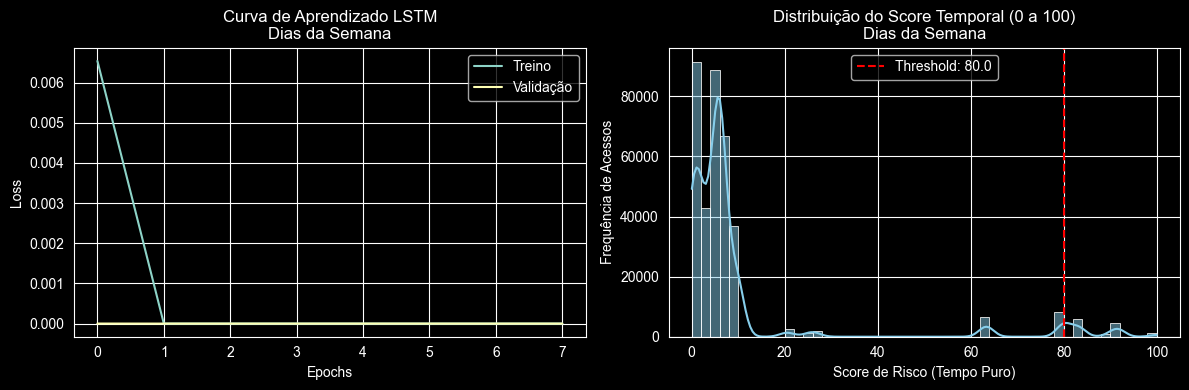

In [15]:
#
# Plota dias da Semana
#
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_weekday.history['loss'], label='Treino')
plt.plot(history_weekday.history['val_loss'], label='Validação')
plt.title('Curva de Aprendizado LSTM\nDias da Semana')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(scores_100_weekday, bins=50, kde=True, color='skyblue')
plt.axvline(threshold_100, color='red', linestyle='--', label=f'Threshold: {threshold_100}')
plt.title('Distribuição do Score Temporal (0 a 100)\nDias da Semana')
plt.xlabel('Score de Risco (Tempo Puro)')
plt.ylabel('Frequência de Acessos')
plt.legend()
plt.tight_layout()
plt.show()

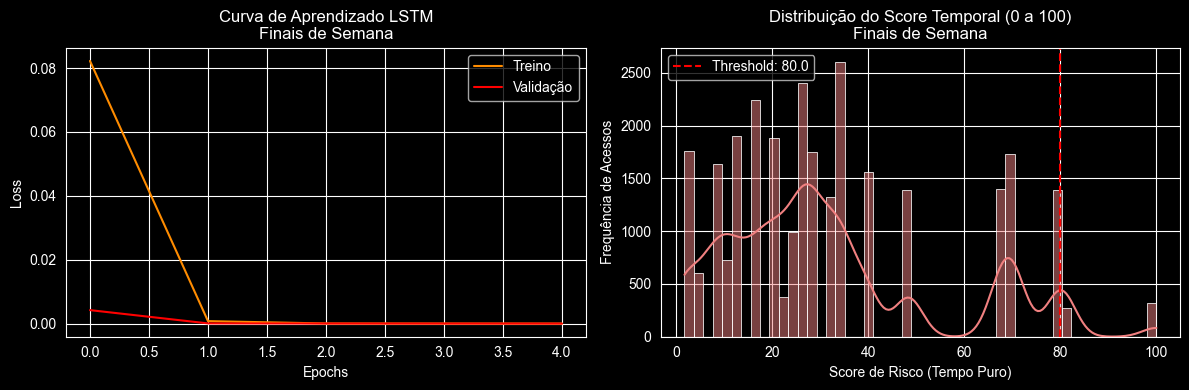

In [16]:
# ==========================================
# GRÁFICOS: FINAIS DE SEMANA
# ==========================================
if len(X_weekend) > 0:
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    # Utilizando cores diferentes (Laranja/Vermelho) para facilitar distinção visual do SOC
    plt.plot(history_weekend.history['loss'], label='Treino', color='darkorange')
    plt.plot(history_weekend.history['val_loss'], label='Validação', color='red')
    plt.title('Curva de Aprendizado LSTM\nFinais de Semana')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    sns.histplot(scores_100_weekend, bins=50, kde=True, color='lightcoral')
    plt.axvline(threshold_100, color='red', linestyle='--', label=f'Threshold: {threshold_100}')
    plt.title('Distribuição do Score Temporal (0 a 100)\nFinais de Semana')
    plt.xlabel('Score de Risco (Tempo Puro)')
    plt.ylabel('Frequência de Acessos')
    plt.legend()
    plt.tight_layout()
    plt.show()

### Consolidação de Desvios Históricos por Usuário em Pipeline Temporal Duplo

Abaixo a função realiza a extração de desvios históricos de forma independente para os subconjuntos de dias úteis e finais de semana, em coerência com a estratégia de modelagem dual adotada no pipeline. A função _extrair_anomalias_historicas_ calcula, para cada sequência temporal, o erro de reconstrução do _autoencoder_ e converte esse valor em um _score_ reescalonado de 0 a 100. Em seguida, os _scores_ são reorganizados por usuário, e o maior valor observado em cada histórico é utilizado como medida sintética do desvio máximo registrado naquele contexto temporal. Com base nesse valor, cada usuário é classificado conforme ultrapasse ou não o limiar de referência adotado. Por fim, os resultados de ambos os contextos são consolidados em uma tabela única, permitindo identificar e ordenar os usuários com maiores desvios históricos em relação ao padrão aprendido pelos modelos.

In [17]:
#
# Função para a coleta de anomalias
#
def extrair_anomalias_historicas(df_grupo, modelo, X_data, thresh_raw, maximo_raw, nome_grupo):
    if len(df_grupo) == 0: return []

    X_pred = modelo.predict(X_data, verbose=0)
    scores_mse_raw = np.mean(np.power(X_data - X_pred, 2), axis=(1, 2))
    scores_100 = np.array([escalar_score_0_a_100(s, thresh_raw, maximo_raw) for s in scores_mse_raw])

    resultados = []
    idx = 0
    for user, group in df_grupo.groupby('Usuário'):
        n_seqs = len(group) - SEQ_LENGTH + 1
        if len(group) < SEQ_LENGTH: n_seqs = 1

        user_scores = scores_100[idx : idx + n_seqs]

        # Prevenção rigorosa do erro de array vazio (zero-size array to reduction operation maximum)
        if len(user_scores) > 0:
            max_score = np.max(user_scores)
            resultados.append({
                'Usuário': user,
                'Contexto': nome_grupo,
                'Score_Risco_Máximo': round(max_score, 1),
                'Status': 'Anômalo' if max_score > 80.0 else 'Normal'
            })
        idx += n_seqs
    return resultados

In [18]:
#
# Coletando anomalias
#
anomalias_semana = extrair_anomalias_historicas(df_weekday, model_weekday, X_weekday, thresh_raw_weekday, max_raw_weekday, 'Dias Úteis')
anomalias_fds = extrair_anomalias_historicas(df_weekend, model_weekend, X_weekend, thresh_raw_weekend, max_raw_weekend, 'Finais de Semana')

In [19]:
#
# Consolidando os resultados no formato de Tabela (DataFrame)
#
df_anomalias = pd.DataFrame(anomalias_semana + anomalias_fds)
if not df_anomalias.empty:
    df_top_anomalos = df_anomalias[df_anomalias['Status'] == 'Anômalo'].sort_values(by='Score_Risco_Máximo', ascending=False)
    print(f"Foram detectadas {len(df_top_anomalos)} anomalias históricas consolidadas nos dois modelos.")
    print("Abaixo, o TOP 10 dos usuários com maior quebra de padrão cronológico:")
    display(df_top_anomalos.head(10))
else:
    print("Nenhuma anomalia detectada no histórico.")

Foram detectadas 2199 anomalias históricas consolidadas nos dois modelos.
Abaixo, o TOP 10 dos usuários com maior quebra de padrão cronológico:


,Usuário,Contexto,Score_Risco_Máximo,Status
2592,USR519073@acme-4cdbb9e8.org.br,Dias Úteis,100.0,Anômalo
4232,USR874474@acme-043bf1cc.org.br,Dias Úteis,100.0,Anômalo
1046,USR209932@acme-043bf1cc.org.br,Dias Úteis,100.0,Anômalo
2768,USR558171@acme-4cdbb9e8.org.br,Dias Úteis,100.0,Anômalo
2764,USR557424@acme-4cdbb9e8.org.br,Dias Úteis,100.0,Anômalo
4168,USR862491@acme-4cdbb9e8.org.br,Dias Úteis,100.0,Anômalo
2738,USR551774@acme-4cdbb9e8.org.br,Dias Úteis,100.0,Anômalo
4186,USR865876@acme-d67a0e6c.org.br,Dias Úteis,100.0,Anômalo
1012,USR203680@acme-4cdbb9e8.org.br,Dias Úteis,100.0,Anômalo
2731,USR550320@acme-d67a0e6c.org.br,Dias Úteis,100.0,Anômalo


### Função para Avaliação de Aderência Temporal de Novos Eventos de Autenticação

A função apresentada realiza a avaliação pontual de um novo evento de acesso com base em seus atributos temporais. A partir da data e da identificação do usuário, o código reconstrói as mesmas variáveis derivadas utilizadas no treinamento, incluindo a codificação cíclica da hora e a separação entre dias úteis e finais de semana. Em seguida, o evento é encaminhado ao modelo correspondente ao seu contexto temporal, utilizando também o respectivo escalonador e os parâmetros estatísticos previamente calculados. O modelo produz a reconstrução da observação, e o erro resultante é convertido em um _score_ de 0 a 100, interpretado como medida de desvio em relação ao padrão temporal aprendido. Adicionalmente, caso o usuário não possua histórico no mesmo contexto temporal, aplica-se uma regra heurística que atribui o _score_ máximo ao evento, sinalizando ausência completa de referência comportamental. Por fim, o _score_ é comparado ao limiar definido no pipeline, permitindo classificar o acesso como compatível ou não com o padrão temporal historicamente observado.

In [20]:
def analisar_log_roteado(log_str, df_historico_raw):
    print('====== AVALIAÇÃO DE COMPORTAMENTO ROTEADA ======')

    # Extração Robusta: Como agora analisamos apenas o tempo, não precisamos do pd.read_csv para a string.
    # Isso evita qualquer desalinhamento de colunas e dados corrompidos como o 'mmdb' ou datas em 1969.
    campos = log_str.strip().split(',')
    if len(campos) < 2:
        print("Erro: Log em formato inválido.")
        return

    data_str = campos[0]
    usuario = campos[1]

    novo_df = pd.DataFrame({'Data': [data_str], 'Usuário': [usuario]})
    novo_df['Data'] = pd.to_datetime(novo_df['Data'], format='mixed')
    novo_df['hour'] = novo_df['Data'].dt.hour
    novo_df['day_of_week'] = novo_df['Data'].dt.dayofweek
    novo_df['is_weekend'] = novo_df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
    novo_df['hour_sin'] = np.sin(2 * np.pi * novo_df['hour'] / 24.0)
    novo_df['hour_cos'] = np.cos(2 * np.pi * novo_df['hour'] / 24.0)

    is_weekend_log = novo_df['is_weekend'].iloc[0] == 1
    grupo_str = "FINAL DE SEMANA" if is_weekend_log else "DIA ÚTIL (Seg-Sex)"

    # Regra de Zero Histórico (Macro Anomalia)
    historico_usuario = df_historico_raw[df_historico_raw['Usuário'] == usuario].copy()
    historico_usuario['is_weekend'] = pd.to_datetime(historico_usuario['Data']).dt.dayofweek >= 5

    qtd_logs_neste_grupo = len(historico_usuario[historico_usuario['is_weekend'] == is_weekend_log])

    print(f'Usuário logado: {usuario}')
    print(f"Data/Hora da Tentativa: {novo_df['Data'].dt.strftime('%d/%m/%Y %H:%M').iloc[0]} -> [{grupo_str}]")

    if qtd_logs_neste_grupo == 0:
        print(f'SCORE DE RISCO: 100.0 / 100')
        print('-> RESULTADO: \033[91mANOMALIA SEVERA (ZERO HISTÓRICO)\033[0m')
        print(f'Motivo: O usuário não possui NENHUM histórico de acessos neste grupo ({grupo_str}). Quebra absoluta de rotina.')
        print('====================================================\n')
        return

    # Roteamento de Parâmetros
    if is_weekend_log:
        modelo_ativo = model_weekend
        scaler_ativo = scaler_weekend
        thresh_ativo = thresh_raw_weekend
        maximo_ativo = max_raw_weekend
    else:
        modelo_ativo = model_weekday
        scaler_ativo = scaler_weekday
        thresh_ativo = thresh_raw_weekday
        maximo_ativo = max_raw_weekday

    # Processamento e Previsão
    dados_finais = novo_df[features_temporais].values
    dados_scaled = scaler_ativo.transform(pd.DataFrame(dados_finais, columns=features_temporais))
    X_teste = dados_scaled.reshape(1, SEQ_LENGTH, len(features_temporais))

    pred = modelo_ativo.predict(X_teste, verbose=0)
    score_raw = np.mean(np.power(X_teste - pred, 2))
    score_final = escalar_score_0_a_100(score_raw, thresh_ativo, maximo_ativo)

    print(f'SCORE DE RISCO: {score_final:.1f} / 100')
    print(f'Limite Máximo Permitido: 80.0 / 100\n')

    if score_final > 80.0:
        print('-> RESULTADO: \033[91mFORA DO HORÁRIO USUAL (ACESSO ANÔMALO!)\033[0m')
    else:
        print('-> RESULTADO: \033[92mDENTRO DO HORÁRIO USUAL (ACESSO NORMAL)\033[0m')
    print('====================================================\n')

### Função para Análise Visual de Hábitos de um Usuário Específico

O trecho de código de função a seguir apresenta, de forma visual, o perfil histórico de acessos de um determinado usuário ao longo de um ciclo de 24 horas, permitindo identificar concentrações, dispersões e eventuais desvios em relação aos horários usualmente observados.

A visualização foi concebida para apoiar uma análise humana pragmática, fornecendo evidências interpretáveis que podem acelerar a triagem e a resposta a incidentes, além de contribuir para atividades de auditoria ao facilitar a contextualização do comportamento temporal do usuário.

In [21]:
def visualizar_habitos_duplos(usuario_alvo, df_raw):
    df_user = df_raw[df_raw['Usuário'] == usuario_alvo].copy()

    if len(df_user) == 0:
        print(f"O usuário '{usuario_alvo}' não foi encontrado na base de dados.")
        return

    df_user['Data'] = pd.to_datetime(df_user['Data'], format='mixed')
    df_user['Hora_Fracionada'] = df_user['Data'].dt.hour + (df_user['Data'].dt.minute / 60.0)
    df_user['is_weekend'] = df_user['Data'].dt.dayofweek >= 5

    df_work = df_user[df_user['is_weekend'] == False]
    df_rest = df_user[df_user['is_weekend'] == True]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Histograma Dias Úteis
    if not df_work.empty:
        sns.histplot(df_work['Hora_Fracionada'], bins=24, binrange=(0, 24), kde=True, color='rebeccapurple', ax=ax1)
    ax1.set_xticks(range(0, 25, 2))
    ax1.set_xlim(0, 24)
    ax1.set_title(f'Distribuição Linear: DIAS ÚTEIS ({len(df_work)} acessos)')
    ax1.set_xlabel('Hora do Dia (0h - 24h)')
    ax1.set_ylabel('Quantidade')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # Histograma Final de Semana
    if not df_rest.empty:
        sns.histplot(df_rest['Hora_Fracionada'], bins=24, binrange=(0, 24), kde=True, color='darkorange', ax=ax2)
    ax2.set_xticks(range(0, 25, 2))
    ax2.set_xlim(0, 24)
    ax2.set_title(f'Distribuição Linear: FINAIS DE SEMANA ({len(df_rest)} acessos)')
    ax2.set_xlabel('Hora do Dia (0h - 24h)')
    ax2.set_ylabel('Quantidade')
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    plt.suptitle(f'Perfil Comportamental Completo: {usuario_alvo}', fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

### Teste de usuário: USR104683@acme-4cdbb9e8.org.br

O teste a seguir tem como finalidade caracterizar o comportamento habitual do usuário a partir de seu histórico de acessos e, em seguida, aplicar regras de decisão sobre novos eventos de entrada. Dessa forma, o procedimento avalia se cada ocorrência é compatível com o padrão aprendido ou se configura um desvio relevante, produzindo um resultado que subsidia a tomada de decisão (por exemplo, classificação de normalidade/anomalia e eventual acionamento de controles).

#### Análise Visual de comportamento de login do usuário

O gráfico a seguir apresenta o perfil comportamental do usuário após o treinamento do modelo **LSTM**, sintetizando o padrão temporal aprendido a partir do histórico de acessos e evidenciando a distribuição esperada de ocorrências ao longo do tempo.

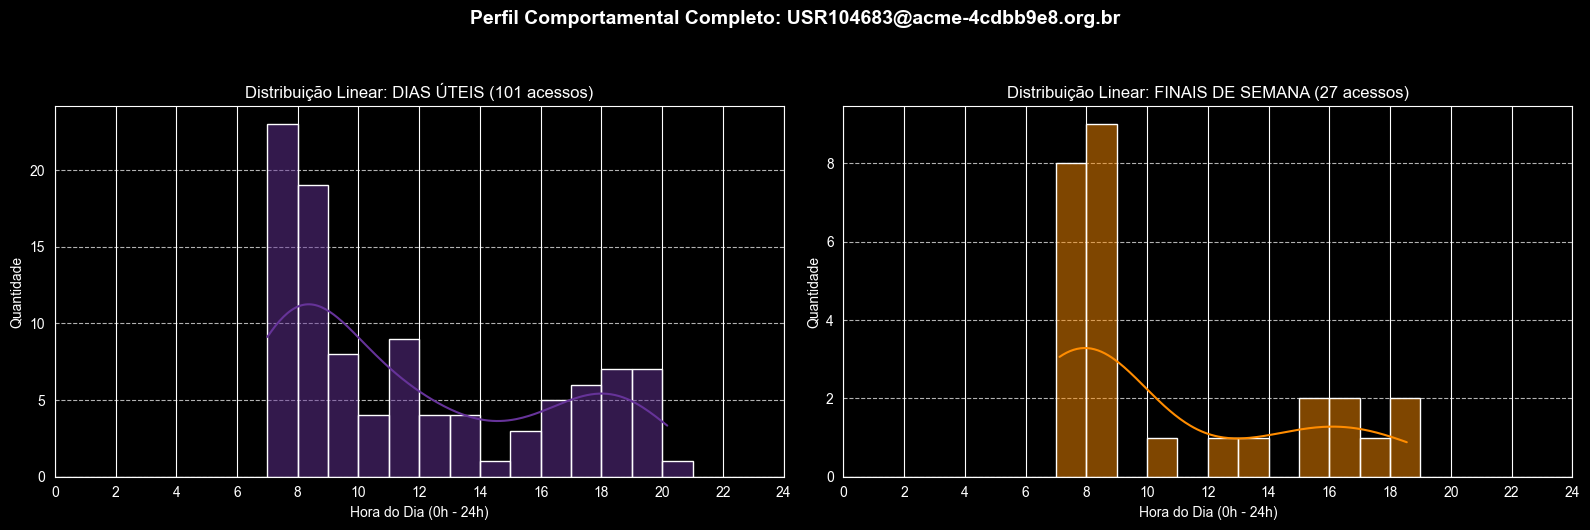

In [22]:

#
# Teste com o usuário solicitado para visualizar seu padrão em 24 horas
#
usuario_exemplo = 'USR104683@acme-4cdbb9e8.org.br'
visualizar_habitos_duplos(usuario_exemplo, df_base)

#### Testes de acesso ao usuário.

O objetivo do procedimento a seguir é analisar um evento de *log* entrante na estrutura e, a partir dele, calcular um *score* que subsidia a tomada de decisão. Esse score orienta tanto a manutenção do acesso (quando o comportamento é compatível com o padrão esperado) quanto a identificação de anomalias, permitindo acionar medidas restritivas proporcionais ao nível de risco estimado.

In [31]:

#
# Simulação de Acesso de um usuário baseado em evento
#

# TESTE 1: Acesso às 14:00 (Dentro da zona quente de acessos visuais - Quarta-feira)
log = '2025-05-14T09:00:00-0300,USR104683@acme-4cdbb9e8.org.br,login_success,USR104683 logged in,none,none,Desconhecido,false,false,,acme.org,SP,SP,BR,BR,5,-23.5,-46.6,mmdb,'
analisar_log_roteado(log, df_base)

# TESTE 2: Acesso às 23:00 da noite (Fora da zona de acesso visual)
log = '2025-05-05T03:00:00-0300,USR104683@acme-4cdbb9e8.org.br,login_success,USR104683 logged in,none,none,Desconhecido,false,false,,acme-4cdbb9e8.org.br,São Paulo,São Paulo,Brazil,BR,5,-23.5475,-46.6361,mmdb,'
analisar_log_roteado(log, df_base)

====== AVALIAÇÃO DE COMPORTAMENTO ROTEADA ======
Usuário logado: USR104683@acme-4cdbb9e8.org.br
Data/Hora da Tentativa: 14/05/2025 09:00 -> [DIA ÚTIL (Seg-Sex)]
SCORE DE RISCO: 2.4 / 100
Limite Máximo Permitido: 80.0 / 100

-> RESULTADO: DENTRO DO HORÁRIO USUAL (ACESSO NORMAL)

====== AVALIAÇÃO DE COMPORTAMENTO ROTEADA ======
Usuário logado: USR104683@acme-4cdbb9e8.org.br
Data/Hora da Tentativa: 05/05/2025 03:00 -> [DIA ÚTIL (Seg-Sex)]
SCORE DE RISCO: 100.0 / 100
Limite Máximo Permitido: 80.0 / 100

-> RESULTADO: FORA DO HORÁRIO USUAL (ACESSO ANÔMALO!)



### Teste de usuário: USR897739@acme-4cdbb9e8.org.br

O teste a seguir tem como finalidade caracterizar o comportamento habitual do usuário a partir de seu histórico de acessos e, em seguida, aplicar regras de decisão sobre novos eventos de entrada. Dessa forma, o procedimento avalia se cada ocorrência é compatível com o padrão aprendido ou se configura um desvio relevante, produzindo um resultado que subsidia a tomada de decisão (por exemplo, classificação de normalidade/anomalia e eventual acionamento de controles).

#### Análise Visual de comportamento de login do usuário

O gráfico a seguir apresenta o perfil comportamental do usuário após o treinamento do modelo **LSTM**, sintetizando o padrão temporal aprendido a partir do histórico de acessos e evidenciando a distribuição esperada de ocorrências ao longo do tempo.

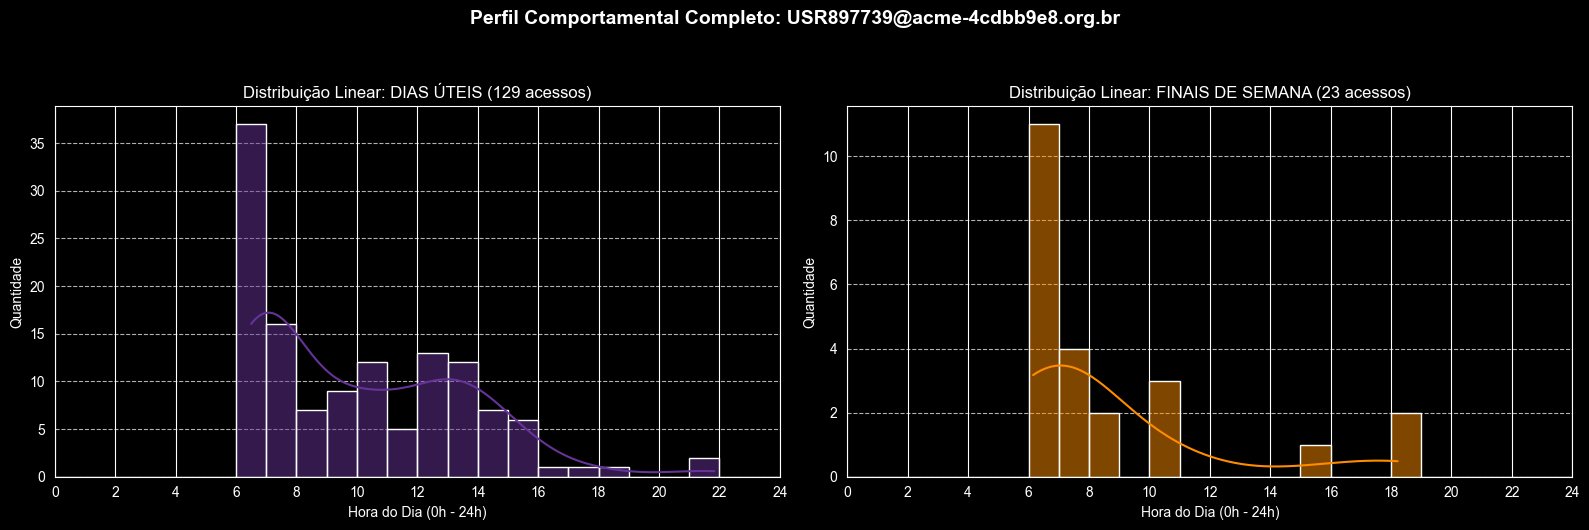

In [24]:

#
# Teste com o usuário solicitado para visualizar seu padrão em 24 horas
#
usuario_exemplo = 'USR897739@acme-4cdbb9e8.org.br'
visualizar_habitos_duplos(usuario_exemplo, df_base)

#### Testes de acesso ao usuário.

O objetivo do procedimento a seguir é analisar um evento de *log* entrante na estrutura e, a partir dele, calcular um *score* que subsidia a tomada de decisão. Esse score orienta tanto a manutenção do acesso (quando o comportamento é compatível com o padrão esperado) quanto a identificação de anomalias, permitindo acionar medidas restritivas proporcionais ao nível de risco estimado.

In [25]:

#
# Simulação de Acesso de um usuário baseado em evento
#

# TESTE 1: Acesso às 11:12 (Dentro da zona quente de acessos visuais - Sexta-feira)
log = '2025-06-06T11:12:14-0300,USR897739@acme-4cdbb9e8.org.br,login_success,USR897739@acme-4cdbb9e8.org.br logged in,google_password,password,Desconhecido,false,false,,acme-4cdbb9e8.org.br,São Paulo,São Paulo,Brazil,BR,20,-23.6293,-46.6351,cache,'
analisar_log_roteado(log, df_base)

# TESTE 2: Acesso às 02:15 da madrugada (Fora da zona de acesso visual - Final de Semana)
log = '2025-07-06T02:15:14-0300,USR897739@acme-4cdbb9e8.org.br,login_success,USR897739@acme-4cdbb9e8.org.br logged in,google_password,password,Desconhecido,false,false,,acme-4cdbb9e8.org.br,São Paulo,São Paulo,Brazil,BR,20,-23.6293,-46.6351,cache,'
analisar_log_roteado(log, df_base)

====== AVALIAÇÃO DE COMPORTAMENTO ROTEADA ======
Usuário logado: USR897739@acme-4cdbb9e8.org.br
Data/Hora da Tentativa: 06/06/2025 11:12 -> [DIA ÚTIL (Seg-Sex)]
SCORE DE RISCO: 6.2 / 100
Limite Máximo Permitido: 80.0 / 100

-> RESULTADO: DENTRO DO HORÁRIO USUAL (ACESSO NORMAL)

====== AVALIAÇÃO DE COMPORTAMENTO ROTEADA ======
Usuário logado: USR897739@acme-4cdbb9e8.org.br
Data/Hora da Tentativa: 06/07/2025 02:15 -> [FINAL DE SEMANA]
SCORE DE RISCO: 100.0 / 100
Limite Máximo Permitido: 80.0 / 100

-> RESULTADO: FORA DO HORÁRIO USUAL (ACESSO ANÔMALO!)

